Training the AI to understand materials...
Training Complete! Now generating a NEW material...
I have invented a new material with properties: [[-1.1977005   0.28271765  1.137353  ]]


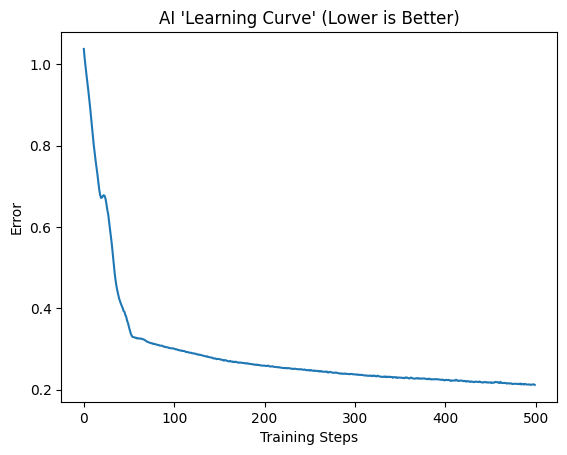

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. CREATE "FAKE" DATA (Simulating the Materials Project)
# Imagine each row is a material with 3 features: [Density, Melting Point, Band Gap]
# In real life, you would load this from your CSV file.
real_data = torch.randn(1000, 3)  # 1000 materials, 3 properties

# 2. BUILD THE AI BRAIN (The VAE Architecture)
class MaterialGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # ENCODER: Compresses the material into a "concept" (Latent Space)
        self.encoder = nn.Sequential(nn.Linear(3, 16), nn.ReLU(), nn.Linear(16, 2))
        
        # DECODER: Takes a "concept" and builds a full material back from it
        self.decoder = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 3))

    def forward(self, x):
        # 1. Encode: Compress the data
        latent_concept = self.encoder(x) 
        # 2. Add "Noise" (The "Variational" part - makes the AI creative)
        noise = torch.randn_like(latent_concept) 
        creative_concept = latent_concept + (0.1 * noise)
        # 3. Decode: Reconstruct the material
        reconstructed = self.decoder(creative_concept)
        return reconstructed

# 3. TRAIN THE BRAIN
model = MaterialGenerator()
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

print("Training the AI to understand materials...")
errors = []
for epoch in range(500):
    optimizer.zero_grad()
    reconstruction = model(real_data)
    loss = loss_fn(reconstruction, real_data)
    loss.backward()
    optimizer.step()
    errors.append(loss.item())

# 4. GENERATE A NEW MATERIAL (The "Dreaming" Part)
print("Training Complete! Now generating a NEW material...")
with torch.no_grad():
    # We give it random noise (an "idea") and ask it to build a material
    random_idea = torch.randn(1, 3) 
    new_material = model(random_idea)
    print(f"I have invented a new material with properties: {new_material.numpy()}")

# 5. SHOW SUCCESS
plt.plot(errors)
plt.title("AI 'Learning Curve' (Lower is Better)")
plt.xlabel("Training Steps")
plt.ylabel("Error")
plt.show()